## Preprocessing


In [ ]:
import pandas as pd
import numpy as np
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("lakshmi25npathi/imdb-dataset-of-50k-movie-reviews")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'imdb-dataset-of-50k-movie-reviews' dataset.
Path to dataset files: /kaggle/input/imdb-dataset-of-50k-movie-reviews


In [ ]:
df = pd.read_csv('/kaggle/input/imdb-dataset-of-50k-movie-reviews/IMDB Dataset.csv')

df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [ ]:
df.sample(3)

,review,sentiment
22687,My first warning should have been that this dv...,negative
12047,I can't even begin to imagine why everyone hat...,positive
3708,This isn't a good movie. Plain and simple. Tak...,negative


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB


In [ ]:
df.rename(columns={'sentiment': 'target'}, inplace=True)
df.rename(columns={'review': 'text'}, inplace=True)

In [ ]:
def encode_label(df):
    labels = {
        'negative': 0,
        'positive': 1
    }

    df['target'] = df['label'].map(labels)

    return df

In [ ]:
labels = {
    'negative': 0,
    'positive': 1
}
df['target'] = df['target'].map(labels)
df['target'] = df['target'].fillna(0).replace([np.inf, -np.inf], 0)
df['target'] = df['target'].astype(int)
df.head()

,review,target
0,One of the other reviewers has mentioned that ...,1
1,A wonderful little production. <br /><br />The...,1
2,I thought this was a wonderful way to spend ti...,1
3,Basically there's a family where a little boy ...,0
4,"Petter Mattei's ""Love in the Time of Money"" is...",1


In [ ]:
# Shuffle the dataset & reset index >> useful before splitting into train/val/test)

df = df.sample(frac=1).reset_index(drop=True)

df.head()

,review,target
0,This movie is great I really enjoyed it.<br />...,1
1,Being a person who does not usually enjoy boxi...,1
2,This was a highly-hyped movie prior to its rel...,0
3,This enjoyable Euro-western opens with a scene...,1
4,How do you make a totally unappealing movie ou...,0


In [ ]:
df.isnull().sum()

,0
text,0
target,0


In [ ]:
df.duplicated().sum()

np.int64(418)

In [ ]:
df.drop_duplicates(inplace = True)
df.duplicated().sum()

np.int64(0)

In [ ]:
df['target'].value_counts()

,count
target,
1,24884
0,24698


In [ ]:
from sklearn.model_selection import train_test_split

# Train-validation-test split: 70-15-15
train_df, temp_df = train_test_split(df, test_size=0.3, random_state=42, stratify=df['target'])
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42, stratify=temp_df['target'])

print(f"Train: {len(train_df)}, Val: {len(val_df)}, Test: {len(test_df)}")

Train: 34707, Val: 7437, Test: 7438


## RoBERTa

In [ ]:
!pip install datasets evaluate
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
from datasets import Dataset
import evaluate
import torch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.5 MB/s eta 0:00:00


In [ ]:
# Load RoBERTa tokenizer and model
checkpoint = "roberta-base"
tokenizer = AutoTokenizer.from_pretrained(checkpoint)
model = AutoModelForSequenceClassification.from_pretrained(checkpoint, num_labels=2)
print("RoBERTa loaded successfully")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


RoBERTa loaded successfully


In [ ]:
# Prepare datasets in HuggingFace format
train_hf = pd.DataFrame({"text": train_df['text'].tolist(), "label": train_df['target'].tolist()})
val_hf = pd.DataFrame({"text": val_df['text'].tolist(), "label": val_df['target'].tolist()})
test_hf = pd.DataFrame({"text": test_df['text'].tolist(), "label": test_df['target'].tolist()})

train_dataset = Dataset.from_pandas(train_hf)
val_dataset = Dataset.from_pandas(val_hf)
test_dataset = Dataset.from_pandas(test_hf)
print("Datasets created")

Datasets created


In [ ]:
# Tokenization function
def tokenize_function(examples):
    return tokenizer(examples["text"], padding="max_length", truncation=True, max_length=512)

In [ ]:
# Tokenize all datasets
print("Tokenizing datasets...")
train_dataset = train_dataset.map(tokenize_function, batched=True)
val_dataset = val_dataset.map(tokenize_function, batched=True)
test_dataset = test_dataset.map(tokenize_function, batched=True)
print("Tokenization complete")

Tokenizing datasets...


Map:   0%|          | 0/34707 [00:00<?, ? examples/s]

Map:   0%|          | 0/7437 [00:00<?, ? examples/s]

Map:   0%|          | 0/7438 [00:00<?, ? examples/s]

Tokenization complete


In [ ]:
# Set format for PyTorch
train_dataset.set_format("torch", columns=["input_ids", "attention_mask", "label"])
val_dataset.set_format("torch", columns=["input_ids", "attention_mask", "label"])
test_dataset.set_format("torch", columns=["input_ids", "attention_mask", "label"])
print("Datasets formatted for PyTorch")

Datasets formatted for PyTorch


In [ ]:
# Metric computation function
def compute_metrics(eval_pred):
    metric = evaluate.load("accuracy")
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    accuracy = metric.compute(predictions=predictions, references=labels)

    from sklearn.metrics import precision_recall_fscore_support
    precision, recall, f1, _ = precision_recall_fscore_support(labels, predictions, average='binary')

    return {
        'accuracy': accuracy['accuracy'],
        'precision': precision,
        'recall': recall,
        'f1': f1
    }


In [ ]:
# Define training arguments
training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",
    logging_dir="./logs",
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    num_train_epochs=2,
    weight_decay=0.01,
    logging_steps=100,
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    report_to="none"
)

In [ ]:
# Initialize Trainer
print("Initializing Trainer...")
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics
)
print("Trainer initialized")

Initializing Trainer...


/tmp/ipython-input-217685592.py:3: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Trainer initialized


In [ ]:
# Train the model
print("Starting RoBERTa training...")
trainer.train()
print("Training completed successfully")

Starting RoBERTa training...


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.205100,0.197593,0.940836,0.922919,0.962487,0.942288
2,0.136900,0.209376,0.947425,0.943692,0.952036,0.947846


Training completed successfully


In [41]:
# Evaluate on test set
print("Evaluating on test set...")
eval_results = trainer.evaluate(test_dataset)

print("\n" + "="*50)
print("DISTILBERT EVALUATION RESULTS")
print("="*50)
print(f"Accuracy: {eval_results['eval_accuracy']:.4f}")
print(f"Precision: {eval_results['eval_precision']:.4f}")
print(f"Recall: {eval_results['eval_recall']:.4f}")
print(f"F1-Score: {eval_results['eval_f1']:.4f}")

Evaluating on test set...



DISTILBERT EVALUATION RESULTS
Accuracy: 0.9478
Precision: 0.9428
Recall: 0.9539
F1-Score: 0.9483


In [ ]:
# Get predictions for confusion matrix and further analysis
predictions = trainer.predict(test_dataset)
preds = np.argmax(predictions.predictions, axis=-1)

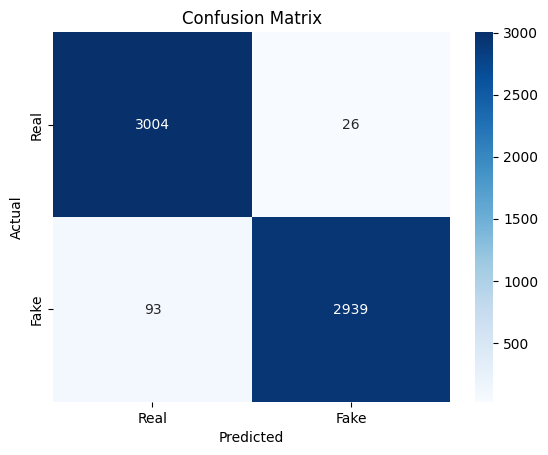

In [ ]:
#Confusion Matrix for evaluation
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(test_df['target'], preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Real', 'Fake'], yticklabels=['Real', 'Fake'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

In [ ]:
save_dir = "/content/drive/MyDrive/distilbert-fake-reviews-final"
model.save_pretrained(save_dir)
tokenizer.save_pretrained(save_dir)

Mounted at /content/drive


('/content/drive/MyDrive/distilbert-fake-reviews-final/tokenizer_config.json',
 '/content/drive/MyDrive/distilbert-fake-reviews-final/special_tokens_map.json',
 '/content/drive/MyDrive/distilbert-fake-reviews-final/vocab.txt',
 '/content/drive/MyDrive/distilbert-fake-reviews-final/added_tokens.json',
 '/content/drive/MyDrive/distilbert-fake-reviews-final/tokenizer.json')